In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as np
df=pd.read_csv(r"C:\Users\ramj0\Downloads\university_query_test.csv")

In [5]:
df.shape

(1000, 5)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Query_ID          1000 non-null   int64 
 1   Student_Query     1000 non-null   object
 2   Department        1000 non-null   object
 3   Days_To_Deadline  1000 non-null   int64 
 4   Priority_Label    1000 non-null   object
dtypes: int64(2), object(3)
memory usage: 39.2+ KB


In [5]:
df.head()

,Query_ID,Student_Query,Department,Days_To_Deadline,Priority_Label
0,2713,LMS is not allowing assignment upload.,IT Support,2,Medium
1,993,How to reset my university portal password?,IT Support,12,Medium
2,2191,I cannot download my hall ticket for tomorrow'...,Academic Office,57,High
3,4671,Fee payment deadline is today but portal is no...,Finance Office,2,High
4,3763,I cannot download my hall ticket for tomorrow'...,IT Support,2,High


In [9]:
df.describe()

,Query_ID,Days_To_Deadline
count,1000.000000,1000.000000
mean,3080.269000,31.182000
std,1711.071767,17.479772
min,4.000000,1.000000
25%,1648.500000,16.000000
50%,3080.500000,32.000000
75%,4594.500000,47.000000
max,5994.000000,60.000000


In [13]:
df.describe(include='object')

,Student_Query,Department,Priority_Label
count,1000,1000,1000
unique,15,7,3
top,Please share syllabus for Data Science course.,Academic Office,Low
freq,86,154,360


In [14]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
995    False
996    False
997    False
998    False
999    False
Length: 1000, dtype: bool

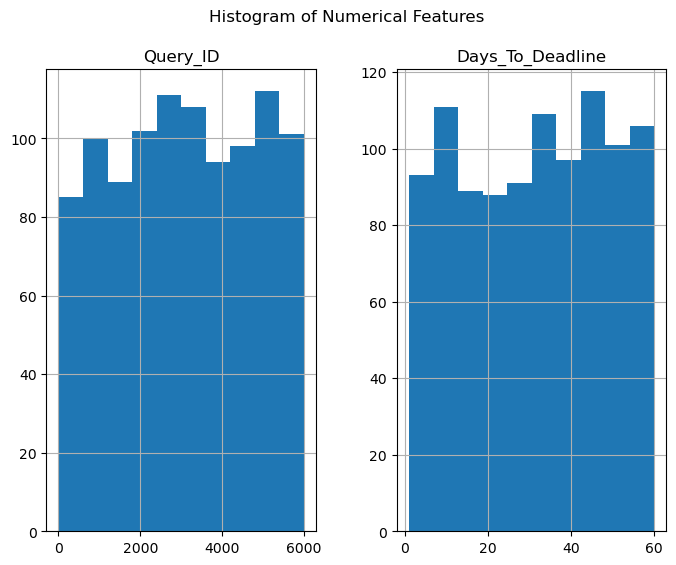

In [7]:
df.hist(figsize=(8,6))
plt.suptitle("Histogram of Numerical Features")
plt.show()

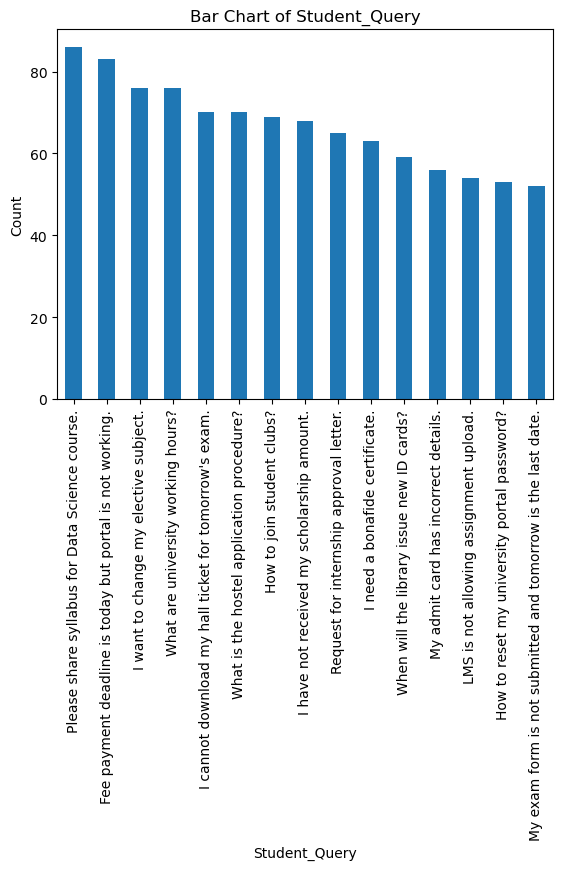

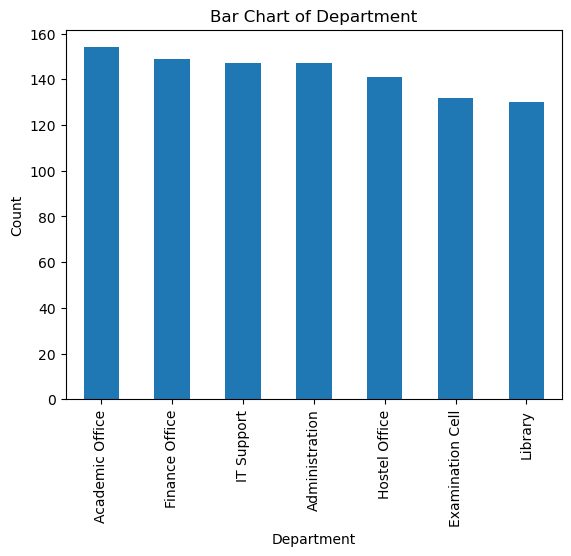

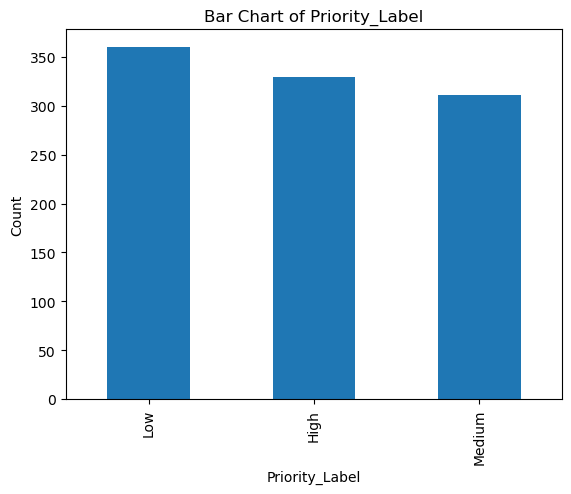

In [10]:
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
  df[col].value_counts().plot(kind='bar')
  plt.title(f"Bar Chart of {col}")
  plt.xlabel(col)
  plt.ylabel("Count")
  plt.xticks(fontsize=10)
  plt.show()

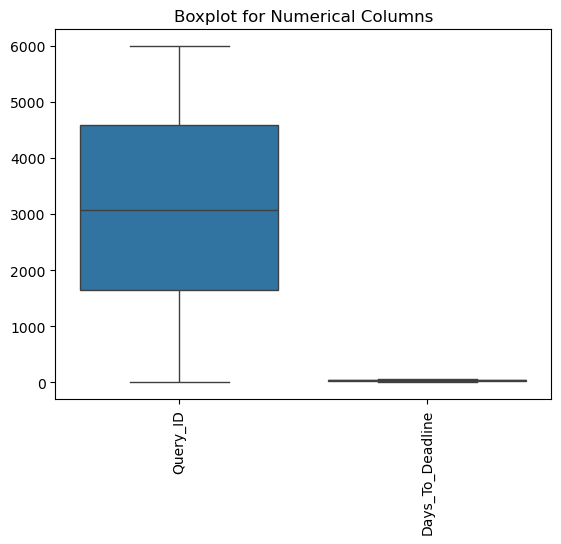

In [64]:

sns.boxplot(data=df.select_dtypes(include=['int64','float64']))
plt.title("Boxplot for Numerical Columns")
plt.xticks(rotation=90)
plt.show()

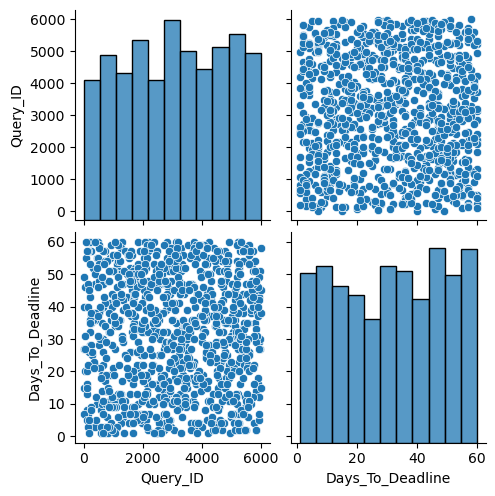

In [65]:
numerical_columns = df.select_dtypes(include=['int64','float64']).columns
sns.pairplot(df[numerical_columns])
plt.show()

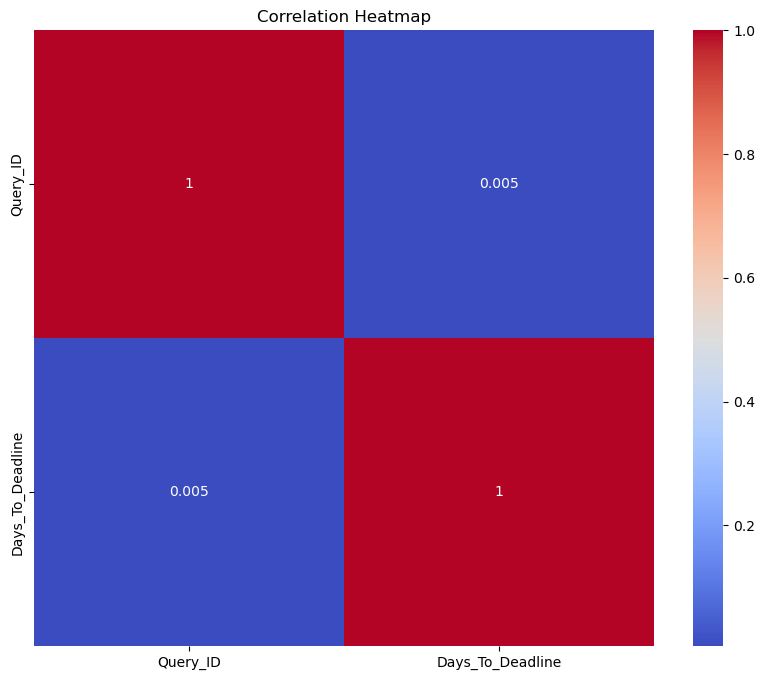

In [69]:
plt.figure(figsize=(10,8))
corr = df.select_dtypes(include=['int64','float64']).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

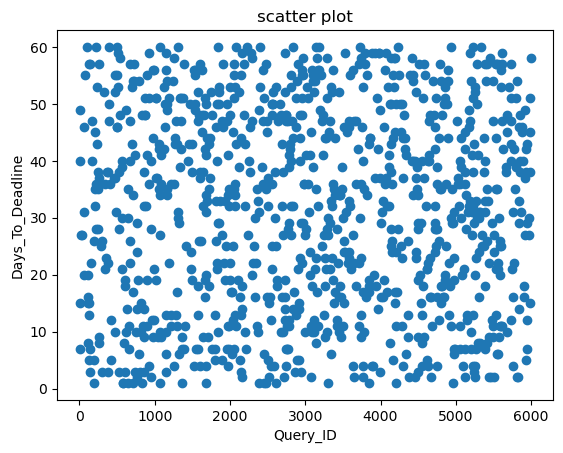

In [7]:
plt.scatter(df['Query_ID'],df['Days_To_Deadline'])
plt.xlabel('Query_ID')
plt.ylabel('Days_To_Deadline')
plt.title('scatter plot')
plt.show()

In [8]:
dept_group = df.groupby("Department").agg(
    Total_Queries=("Query_ID", "count"),
    Avg_Days_To_Deadline=("Days_To_Deadline", "mean")
).reset_index()

print(dept_group)

         Department  Total_Queries  Avg_Days_To_Deadline
0   Academic Office            154             29.681818
1    Administration            147             29.469388
2  Examination Cell            132             34.060606
3    Finance Office            149             33.020134
4     Hostel Office            141             32.539007
5        IT Support            147             29.632653
6           Library            130             30.146154


In [9]:
priority_group = df.groupby("Priority_Label").agg(
    Total_Queries=("Query_ID", "count")
).reset_index()

print(priority_group)

  Priority_Label  Total_Queries
0           High            329
1            Low            360
2         Medium            311


In [24]:
numeric_cols=df.select_dtypes(include=['int64','float64']).columns
result=df.groupby('Department')[numeric_cols].agg(['mean','sum','max','min','count'])
print(result)

                     Query_ID                          Days_To_Deadline        \
                         mean     sum   max  min count             mean   sum   
Department                                                                      
Academic Office   2920.402597  449742  5977   10   154        29.681818  4571   
Administration    3004.714286  441693  5946   56   147        29.469388  4332   
Examination Cell  3030.174242  399983  5987    5   132        34.060606  4496   
Finance Office    3275.281879  488017  5944    4   149        33.020134  4920   
Hostel Office     3026.737589  426770  5854  120   141        32.539007  4588   
IT Support        3385.605442  497684  5994   35   147        29.632653  4356   
Library           2895.230769  376380  5992    6   130        30.146154  3919   

                                
                 max min count  
Department                      
Academic Office   60   1   154  
Administration    60   1   147  
Examination Cell  60   1

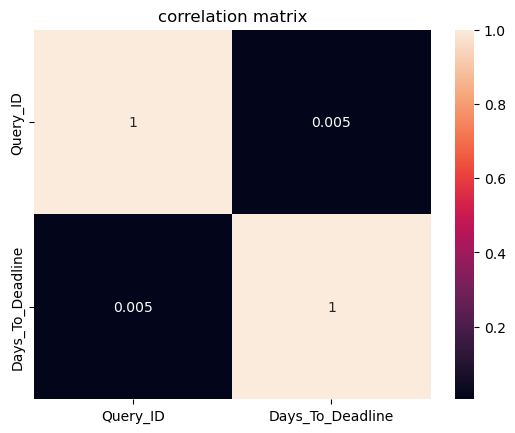

In [26]:
numeric_df=df.select_dtypes(include=['int64','float64'])
corr_matrix=numeric_df.corr()
sns.heatmap(corr_matrix,annot=True)
plt.title("correlation matrix")
plt.show()

In [28]:
categorical_cols=df.select_dtypes(include='object').columns
numeric_cols=df.select_dtypes(include=['int64','float64']).columns
pivot=pd.pivot_table(df,index=categorical_cols[0],columns=categorical_cols[1],values=numeric_cols[0],aggfunc='mean')
print(pivot)

Department                                          Academic Office  \
Student_Query                                                         
Fee payment deadline is today but portal is not...      4697.700000   
How to join student clubs?                              3154.222222   
How to reset my university portal password?             2365.700000   
I cannot download my hall ticket for tomorrow's...      3304.000000   
I have not received my scholarship amount.              2696.857143   
I need a bonafide certificate.                          2777.000000   
I want to change my elective subject.                   2979.153846   
LMS is not allowing assignment upload.                  3451.500000   
My admit card has incorrect details.                    2168.416667   
My exam form is not submitted and tomorrow is t...      2997.500000   
Please share syllabus for Data Science course.          2676.750000   
Request for internship approval letter.                 2601.692308   
What a

In [30]:
numeric_cols=df.select_dtypes(include=['int64','float64']).columns
result=df.groupby('Department')[numeric_cols].agg(lambda x:x.mean())
print(result)

                     Query_ID  Days_To_Deadline
Department                                     
Academic Office   2920.402597         29.681818
Administration    3004.714286         29.469388
Examination Cell  3030.174242         34.060606
Finance Office    3275.281879         33.020134
Hostel Office     3026.737589         32.539007
IT Support        3385.605442         29.632653
Library           2895.230769         30.146154


In [6]:
def Days_To_Deadline(value):
    if value < 55:
        return "Low"
    elif value < 50:
        return "Medium"
    else:
        return "High"

Days_To_Deadline(1000)

'High'

In [9]:
def categorize_level(x):
    if x <= 5:
        return 'Low'
    elif x <= 10:
        return 'Medium'
    else:
        return 'High'
df['Level'] = df['Days_To_Deadline'].apply(categorize_level)
print(df[['Days_To_Deadline', 'Level']].head())

   Days_To_Deadline Level
0                 2   Low
1                12  High
2                57  High
3                 2   Low
4                 2   Low
